# WBC Classifier Comparison
**Models:** SVM · Random Forest · KNN · Soft-Vote Ensemble  
**Data:** `reduced_features.csv` — Original images only (`augmented==0`), augmented rows added to train  
**Strategy:** Split originals 80/20 first → attach augmented to train only (zero leakage)

## 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm                 import SVC
from sklearn.ensemble            import RandomForestClassifier, VotingClassifier
from sklearn.neighbors           import KNeighborsClassifier
from sklearn.pipeline            import Pipeline
from sklearn.preprocessing       import StandardScaler, LabelEncoder
from sklearn.model_selection     import (StratifiedKFold, cross_val_score,
                                          cross_validate)
from sklearn.metrics             import (classification_report,
                                          confusion_matrix,
                                          accuracy_score, f1_score)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

print('All imports OK')

All imports OK


## 2 — Config

In [2]:
CSV_PATH          = 'reduced_features.csv'
LABEL_COL         = 'Label'
NON_FEATURE_COLS  = ['Filepath', 'Source', 'augmented', LABEL_COL]
RANDOM_SEED       = 42
CV_FOLDS          = 5
MIN_TEST_PER_CLASS = 100    # minimum test samples per class
TEST_SIZE         = 0.20

# ── Best SVM params from hyperparameter search ────────────────────────────────
SVM_C      = 51526.9512
SVM_GAMMA  = 0.0010108747
SVM_KERNEL = 'rbf'

## 3 — Load Data & Leakage-Safe Split

In [3]:
df = pd.read_csv(CSV_PATH)
print(f'Loaded  : {len(df):,} rows')

feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
print(f'Features: {len(feature_cols)}')

# ── Per-class minimum-guaranteed split on originals ───────────────────────────
originals = df[df['augmented'] == 0].reset_index(drop=True)
print(f'\nOriginals (augmented==0): {len(originals):,} rows')
print(f'\n{"Class":<15} {"Total":>6} {"Test":>6} {"Train":>6}')
print('─' * 35)

train_parts, test_parts = [], []
for label, grp in originals.groupby(LABEL_COL):
    grp    = grp.sample(frac=1, random_state=RANDOM_SEED)
    n_test = max(int(len(grp) * TEST_SIZE), MIN_TEST_PER_CLASS)
    n_test = min(n_test, len(grp))
    test_parts.append(grp.iloc[:n_test])
    train_parts.append(grp.iloc[n_test:])
    print(f'{label:<15} {len(grp):>6} {n_test:>6} {len(grp)-n_test:>6}')

orig_train = pd.concat(train_parts, ignore_index=True)
orig_test  = pd.concat(test_parts,  ignore_index=True)

# ── Attach augmented rows to train only ───────────────────────────────────────
augmented = df[df['augmented'] != 0]
train_df  = pd.concat([orig_train, augmented], ignore_index=True)

X_train = train_df[feature_cols].values
y_train = train_df[LABEL_COL].values
X_test  = orig_test[feature_cols].values
y_test  = orig_test[LABEL_COL].values

print(f'\nTrain : {len(X_train):,}  (originals: {len(orig_train):,} + augmented: {len(augmented):,})')
print(f'Test  : {len(X_test):,}   (originals only — no leakage)')
print(f'Classes: {sorted(set(y_train))}')

Loaded  : 27,987 rows
Features: 19

Originals (augmented==0): 10,851 rows

Class            Total   Test  Train
───────────────────────────────────
basophil           202    100    102
eosinophil        2753    550   2203
erythroblast       450    100    350
ig                2354    470   1884
lymphocyte         176    100     76
monocyte           328    100    228
neutrophil        3166    633   2533
platelet          1422    284   1138

Train : 25,650  (originals: 8,514 + augmented: 17,136)
Test  : 2,337   (originals only — no leakage)
Classes: ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


## 4 — Define Models

In [4]:
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(C=SVM_C, gamma=SVM_GAMMA, kernel=SVM_KERNEL,
                   probability=True,           # needed for soft-vote
                   class_weight='balanced',
                   decision_function_shape='ovr',
                   random_state=RANDOM_SEED)),
])

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(n_estimators=500,
                                      class_weight='balanced',
                                      random_state=RANDOM_SEED,
                                      n_jobs=-1)),
])

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    KNeighborsClassifier(n_neighbors=7,
                                    weights='distance',
                                    n_jobs=-1)),
])

# Soft-vote ensemble — each estimator must support predict_proba
voting_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    VotingClassifier(
        estimators=[
            ('svm', SVC(C=SVM_C, gamma=SVM_GAMMA, kernel=SVM_KERNEL,
                        probability=True, class_weight='balanced',
                        decision_function_shape='ovr', random_state=RANDOM_SEED)),
            ('rf',  RandomForestClassifier(n_estimators=500,
                                           class_weight='balanced',
                                           random_state=RANDOM_SEED, n_jobs=-1)),
            ('knn', KNeighborsClassifier(n_neighbors=7,
                                         weights='distance', n_jobs=-1)),
        ],
        voting='soft',
    )),
])

models = {
    'SVM'      : svm_pipe,
    'Random Forest' : rf_pipe,
    'KNN'      : knn_pipe,
    'Soft-Vote Ensemble' : voting_pipe,
}

print('Models defined:', list(models.keys()))

Models defined: ['SVM', 'Random Forest', 'KNN', 'Soft-Vote Ensemble']


## 5 — Cross-Validation (5-Fold)

In [5]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

cv_results = {}

for name, model in models.items():
    print(f'\nCV  →  {name} ...', flush=True)
    t0     = time.time()
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='accuracy', n_jobs=-1)
    elapsed = time.time() - t0
    cv_results[name] = scores
    print(f'  Accuracy : {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%'
          f'  |  folds: {[f"{s*100:.1f}%" for s in scores]}'
          f'  |  {elapsed/60:.1f} min')

print('\nAll CV done.')


CV  →  SVM ...
  Accuracy : 93.25% ± 0.43%  |  folds: ['93.6%', '93.1%', '93.9%', '92.9%', '92.7%']  |  2.0 min

CV  →  Random Forest ...
  Accuracy : 91.10% ± 0.37%  |  folds: ['91.7%', '91.0%', '91.1%', '91.1%', '90.5%']  |  0.6 min

CV  →  KNN ...
  Accuracy : 89.33% ± 0.19%  |  folds: ['89.6%', '89.4%', '89.5%', '89.1%', '89.1%']  |  0.1 min

CV  →  Soft-Vote Ensemble ...
  Accuracy : 93.03% ± 0.49%  |  folds: ['93.3%', '93.0%', '93.8%', '92.7%', '92.4%']  |  2.7 min

All CV done.


## 6 — Train on Full Train Set & Evaluate on Test Set

In [6]:
test_results   = {}
class_reports  = {}
conf_matrices  = {}
CLASSES        = sorted(set(y_train))

for name, model in models.items():
    print(f'\nFitting & evaluating  →  {name} ...', flush=True)
    t0 = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')

    test_results[name]  = {'accuracy': acc, 'macro_f1': f1,
                            'time_min': (time.time()-t0)/60}
    class_reports[name] = classification_report(y_test, y_pred,
                                                 labels=CLASSES, digits=4)
    conf_matrices[name] = confusion_matrix(y_test, y_pred, labels=CLASSES)

    print(f'  Test Accuracy : {acc*100:.2f}%  |  Macro F1 : {f1*100:.2f}%'
          f'  |  {(time.time()-t0)/60:.1f} min')

print('\nAll models evaluated.')


Fitting & evaluating  →  SVM ...
  Test Accuracy : 93.24%  |  Macro F1 : 91.55%  |  2.4 min

Fitting & evaluating  →  Random Forest ...
  Test Accuracy : 89.09%  |  Macro F1 : 85.83%  |  0.1 min

Fitting & evaluating  →  KNN ...
  Test Accuracy : 87.46%  |  Macro F1 : 83.02%  |  0.0 min

Fitting & evaluating  →  Soft-Vote Ensemble ...
  Test Accuracy : 91.36%  |  Macro F1 : 89.14%  |  2.4 min

All models evaluated.


## 7 — Side-by-Side Model Comparison

In [7]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'       : list(test_results.keys()),
    'CV Acc (%)'  : [cv_results[m].mean()*100   for m in test_results],
    'CV Std (%)'  : [cv_results[m].std()*100    for m in test_results],
    'Test Acc (%)': [test_results[m]['accuracy']*100 for m in test_results],
    'Macro F1 (%)': [test_results[m]['macro_f1']*100 for m in test_results],
    'Train Time (min)': [test_results[m]['time_min'] for m in test_results],
}).set_index('Model').round(2)

print('='*65)
print('MODEL COMPARISON SUMMARY')
print('='*65)
print(summary.to_string())
print('='*65)

MODEL COMPARISON SUMMARY
                    CV Acc (%)  CV Std (%)  Test Acc (%)  Macro F1 (%)  Train Time (min)
Model                                                                                   
SVM                      93.25        0.43         93.24         91.55              2.38
Random Forest            91.10        0.37         89.09         85.83              0.13
KNN                      89.33        0.19         87.46         83.02              0.00
Soft-Vote Ensemble       93.03        0.49         91.36         89.14              2.42


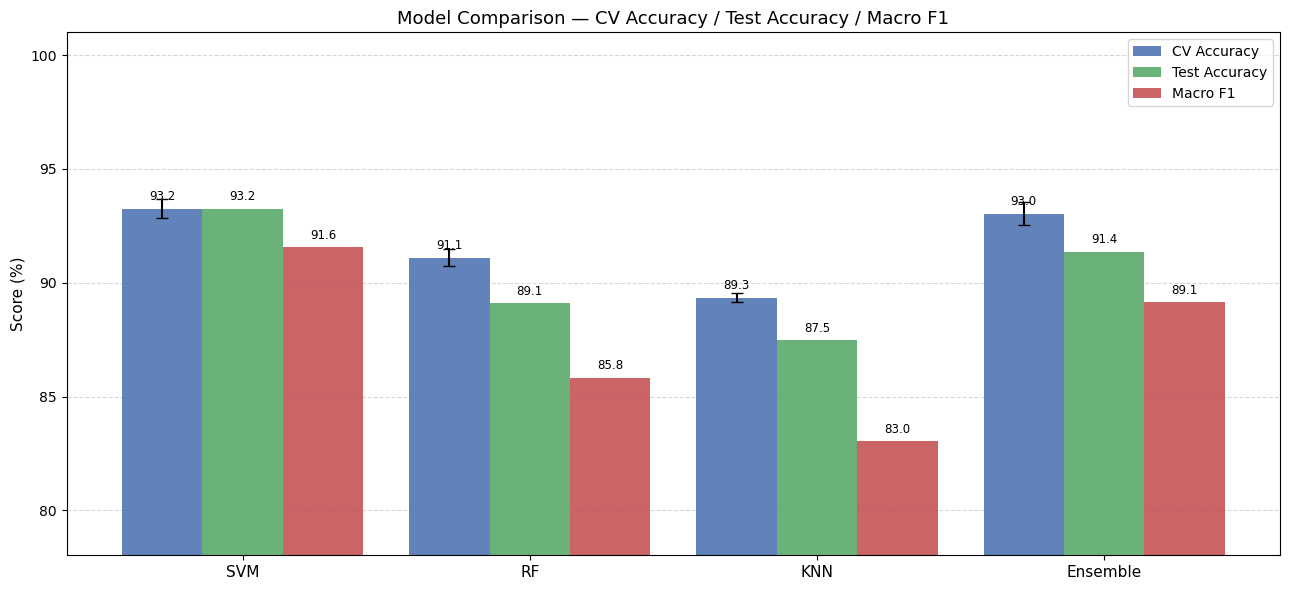

In [8]:
# ── Bar chart comparison ───────────────────────────────────────────────────────
model_names  = list(test_results.keys())
short_names  = ['SVM', 'RF', 'KNN', 'Ensemble']
cv_means     = [cv_results[m].mean()*100 for m in model_names]
cv_stds      = [cv_results[m].std()*100  for m in model_names]
test_accs    = [test_results[m]['accuracy']*100 for m in model_names]
macro_f1s    = [test_results[m]['macro_f1']*100 for m in model_names]

x     = np.arange(len(model_names))
width = 0.28
COLORS = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width, cv_means,  width, label='CV Accuracy',   color=COLORS[0],
            yerr=cv_stds, capsize=4, alpha=0.88)
b2 = ax.bar(x,          test_accs, width, label='Test Accuracy', color=COLORS[1], alpha=0.88)
b3 = ax.bar(x + width,  macro_f1s, width, label='Macro F1',      color=COLORS[2], alpha=0.88)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.25,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Model Comparison — CV Accuracy / Test Accuracy / Macro F1', fontsize=13)
ax.set_ylim(min(cv_means + test_accs + macro_f1s) - 5, 101)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150)
plt.show()

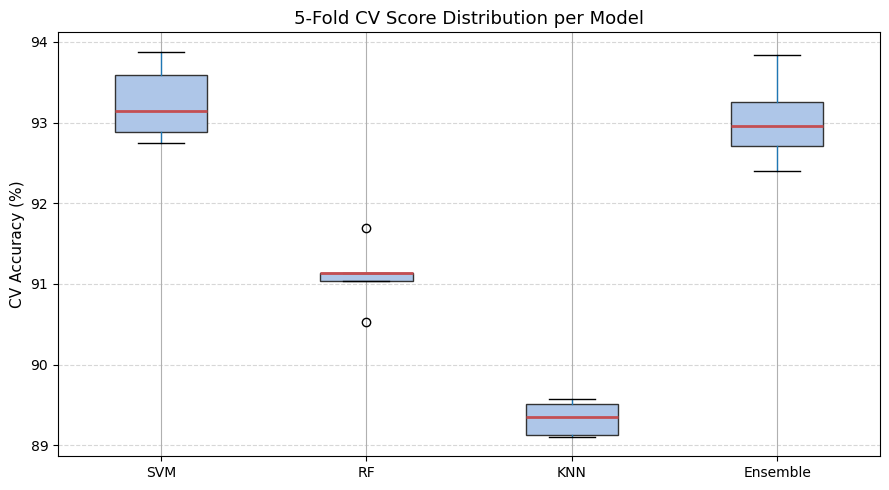

In [9]:
# ── CV fold score distributions (box plot) ────────────────────────────────────
cv_df = pd.DataFrame({m: cv_results[m]*100 for m in model_names})
cv_df.columns = short_names

fig, ax = plt.subplots(figsize=(9, 5))
cv_df.boxplot(ax=ax, patch_artist=True,
              boxprops=dict(facecolor='#AEC6E8', color='#333'),
              medianprops=dict(color='#C44E52', linewidth=2))
ax.set_ylabel('CV Accuracy (%)', fontsize=11)
ax.set_title('5-Fold CV Score Distribution per Model', fontsize=13)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_cv_boxplot.png', dpi=150)
plt.show()

## 8 — Classification Reports

In [10]:
for name, report in class_reports.items():
    print(f'\n{"─"*60}')
    print(f'  {name}')
    print(f'{"─"*60}')
    print(report)


────────────────────────────────────────────────────────────
  SVM
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    basophil     0.8426    0.9100    0.8750       100
  eosinophil     0.9831    0.9509    0.9667       550
erythroblast     0.8261    0.9500    0.8837       100
          ig     0.9069    0.8702    0.8882       470
  lymphocyte     0.9135    0.9500    0.9314       100
    monocyte     0.7982    0.9100    0.8505       100
  neutrophil     0.9502    0.9352    0.9427       633
    platelet     0.9759    0.9965    0.9861       284

    accuracy                         0.9324      2337
   macro avg     0.8996    0.9341    0.9155      2337
weighted avg     0.9344    0.9324    0.9328      2337


────────────────────────────────────────────────────────────
  Random Forest
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    basophil     0.6641   

## 9 — Per-Class F1 Comparison Heatmap

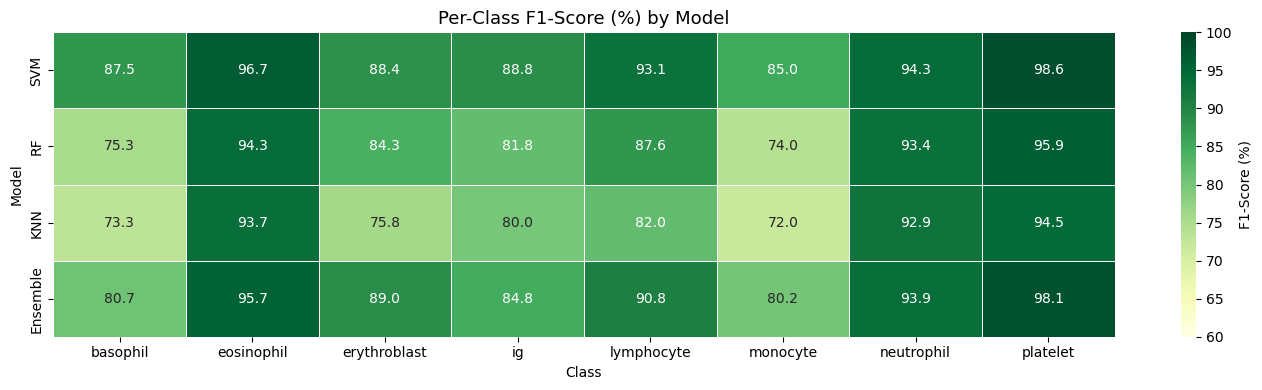

In [11]:
from sklearn.metrics import classification_report as cr

f1_rows = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    rep    = cr(y_test, y_pred, labels=CLASSES, output_dict=True)
    f1_rows[name] = {cls: rep[cls]['f1-score']*100 for cls in CLASSES}

f1_df = pd.DataFrame(f1_rows).T      # rows=models, cols=classes
f1_df.index = short_names

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(f1_df, annot=True, fmt='.1f', cmap='YlGn',
            vmin=60, vmax=100, ax=ax,
            cbar_kws={'label': 'F1-Score (%)'},
            linewidths=0.5)
ax.set_title('Per-Class F1-Score (%) by Model', fontsize=13)
ax.set_xlabel('Class'); ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig('per_class_f1_heatmap.png', dpi=150)
plt.show()

## 10 — Confusion Matrices (All Models)

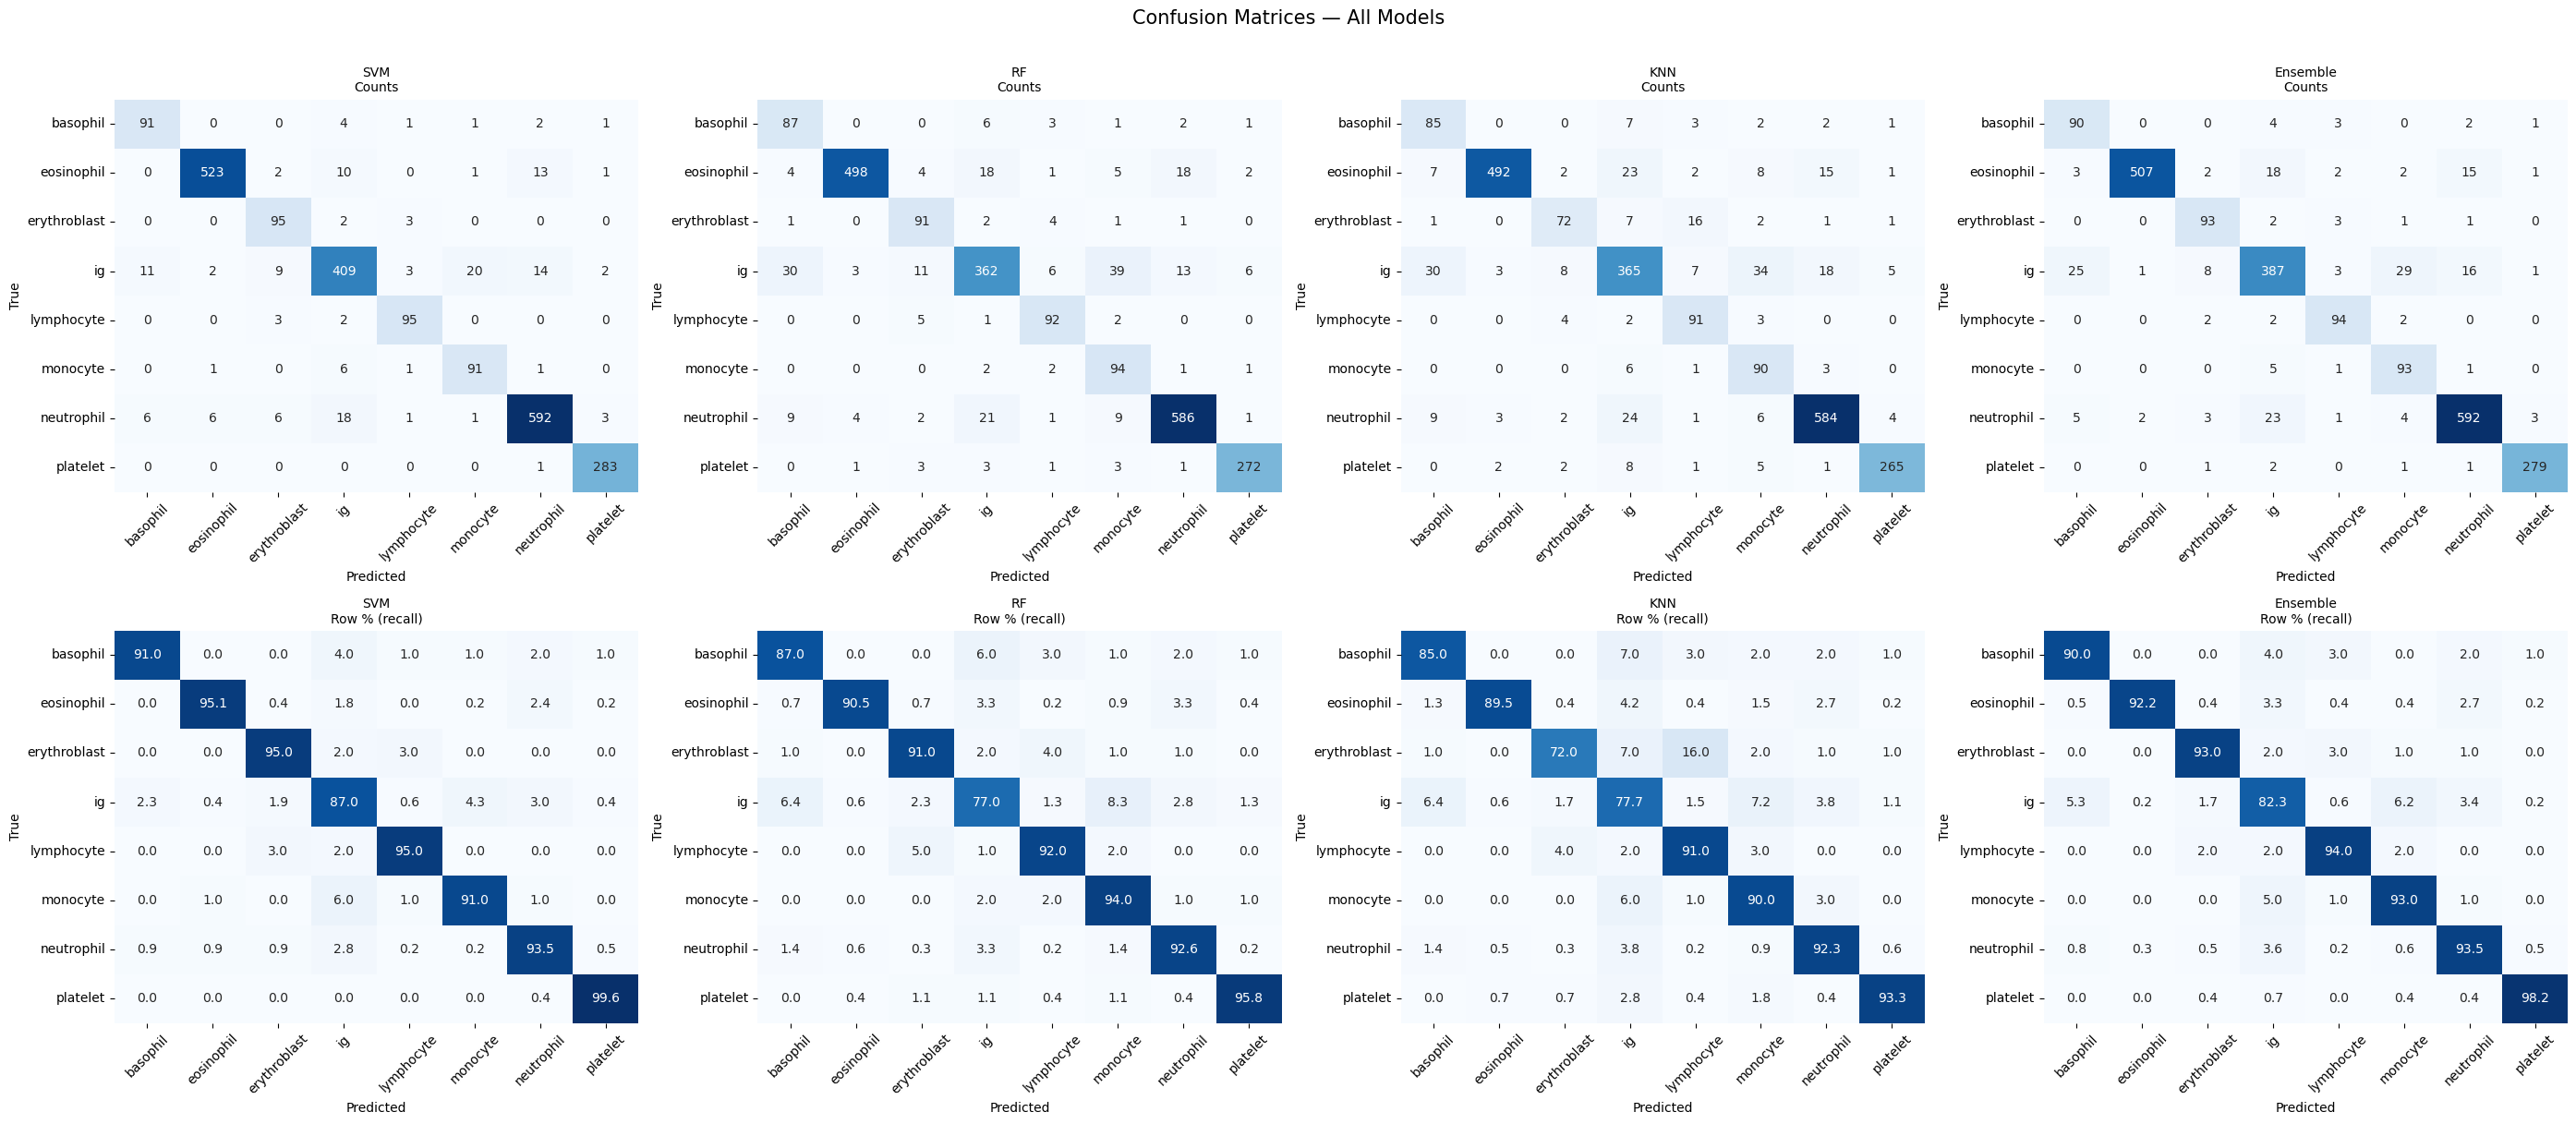

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(28, 12))

for col, (name, cm) in enumerate(conf_matrices.items()):
    # counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=axes[0, col], cbar=False)
    axes[0, col].set_title(f'{short_names[col]}\nCounts', fontsize=10)
    axes[0, col].set_xlabel('Predicted'); axes[0, col].set_ylabel('True')
    axes[0, col].tick_params(axis='x', rotation=45)

    # row-normalised %
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=axes[1, col], vmin=0, vmax=100, cbar=False)
    axes[1, col].set_title(f'{short_names[col]}\nRow % (recall)', fontsize=10)
    axes[1, col].set_xlabel('Predicted'); axes[1, col].set_ylabel('True')
    axes[1, col].tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrices — All Models', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 11 — Final Summary Table

In [13]:
summary_styled = summary.style \
    .background_gradient(subset=['CV Acc (%)', 'Test Acc (%)', 'Macro F1 (%)'],
                         cmap='YlGn', vmin=85, vmax=100) \
    .format('{:.2f}') \
    .set_caption('Model Comparison Summary')

summary_styled

,CV Acc (%),CV Std (%),Test Acc (%),Macro F1 (%),Train Time (min)
Model,,,,,
SVM,93.25,0.43,93.24,91.55,2.38
Random Forest,91.10,0.37,89.09,85.83,0.13
KNN,89.33,0.19,87.46,83.02,0.00
Soft-Vote Ensemble,93.03,0.49,91.36,89.14,2.42
